<h1 style="text-align: center; color: darkblue;">Report</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Helper Functions](#3)
4. [Best Model Summary](#4)
5. [Results on Test set](#5)
6. [Conclusions](#6)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>

This notebook presents the results of the project.

We first summarize the training configuration and validation performance of the selected model, including its key parameters and metrics.
Next, we assess its generalization ability on the test set, reporting the main classification metrics — accuracy, precision, recall, and F1-score — along with the ROC curves and confusion matrix to provide a more detailed view of the model’s behavior across classes.

## <a id="2" style="color: darkred; text-decoration: none;">2. Setup</a>

In [1]:
import pandas as pd
import mlflow
import matplotlib.pyplot as plt
from PIL import Image
import os

from mlflow.tracking import MlflowClient

from pathlib import Path

In [2]:
mlflow_path = Path().resolve().parent / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_path}")

In [3]:
# ANSI codes
BOLD = "\033[1m"
CYAN = "\033[36m"
RESET = "\033[0m"
ORANGE = "\033[38;5;208m"

## <a id="3" style="color: darkred; text-decoration: none;">3. Helper Functions </a>

In [4]:
# best model (according to f1)
def select_best_model(experiment_name, metric="f1", model_type=None, data_version="v1"):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    # Build filter
    filter_str = f"run_name = 'Tuning' AND tags.data_version = '{data_version}'"
    if model_type:
        filter_str += f" AND tags.model_type = '{model_type}'"

    # Search runs
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_str,
        order_by=[f"metrics.{metric} DESC"],
    )

    if not runs:
        raise ValueError(f"No runs found for model_type='{model_type}' and data_version='{data_version}'.")

    # Return best run
    return runs[0]

In [5]:
# get test_data
def get_test_data(experiment_name, tuning_run_id, data_version="v1"):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    # Build filter
    filter_str = f"run_name = 'test_evaluation' AND tags.data_version = '{data_version}'"
    filter_str += f" AND tags.tuning_run_id = '{tuning_run_id}'"

    # Search runs
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_str,
    )

    if not runs:
        raise ValueError(f"No runs found")

    # return
    return runs[0]

In [6]:
# Plotting
def plot_curve(path, figsize=(10, 8)):
    img_cm = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(img_cm)
    plt.axis("off")
    plt.show()


## <a id="4" style="color: darkred; text-decoration: none;">4. Best Model Summary </a>

In [7]:
run = select_best_model("network_security")


# Get metrics and params
metrics = run.data.metrics
params = run.data.params


# Converto to dataframe
df_params = pd.DataFrame({
    "param": list(params.keys()),
    "value": list(params.values())
})


df = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})

2025/11/13 18:08:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/13 18:08:33 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


In [8]:
print(f"\n{BOLD}{ORANGE}PARAMETERS\n----------{RESET}\n")

print(f"{BOLD}Model type{RESET}: {run.data.tags['model_type']}\n")

df_params


PARAMETERS
----------

Model type: tree



,param,value
0,balance_factor,0.2
1,val_size,0.1
2,train_shape,"(169235, 78)"
3,val_shape,"(7731, 78)"
4,criterion,entropy
5,max_depth,16
6,min_samples_split,8


In [9]:
print(f"\n{BOLD}{ORANGE}METRICS\n-------{RESET}\n")

df


METRICS
-------



,metric,value
0,accuracy,0.997413
1,precision,0.997471
2,recall,0.997413
3,f1,0.997435


Accuracy: 0.9977 → The model correctly predicts ~99.77% of all samples. Very high overall performance.

Precision: 0.9977 → When the model predicts a positive class, it is correct ~99.77% of the time. Few false positives.

Recall: 0.9977 → The model captures ~99.77% of actual positive cases. Very few false negatives.

F1-score: 0.9977 → Precision and recall are balanced, indicating the model is reliable across both types of errors.

Overall: The model performs extremely well, with very high and consistent metrics. It shows almost perfect classification with minimal errors.

## <a id="5" style="color: darkred; text-decoration: none;">5. Results on test set </a>

In [10]:
r = get_test_data('network_security', run.info.run_id)

In [11]:
print(f"\n{BOLD}{ORANGE}METRICS ON THE TEST SET\n-----------------------{RESET}\n")

metrics_test = r.data.metrics

# Converto to dataframe
df_metrics_test = pd.DataFrame({
    "param": list(metrics_test.keys()),
    "value": list(metrics_test.values())
})


df_metrics_test


METRICS ON THE TEST SET
-----------------------



,param,value
0,accuracy,0.998101
1,precision,0.998106
2,recall,0.998101
3,f1,0.998101


**Plots**

In [12]:
artifact_uri = run.info.artifact_uri
print(artifact_uri)

/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security/mlruns/1/9699918508f84749b1fdf6f873e09d8e/artifacts


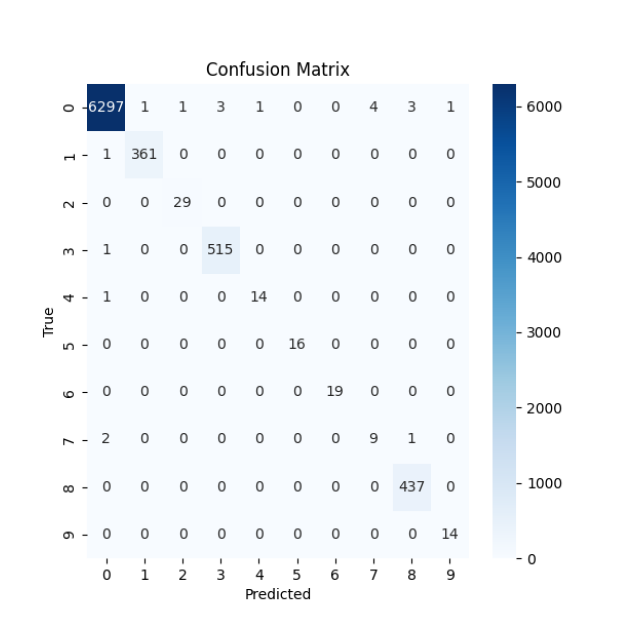

In [13]:
cm_path = os.path.join(artifact_uri, "confusion_matrix.png")

plot_curve(cm_path, figsize=(10, 8))

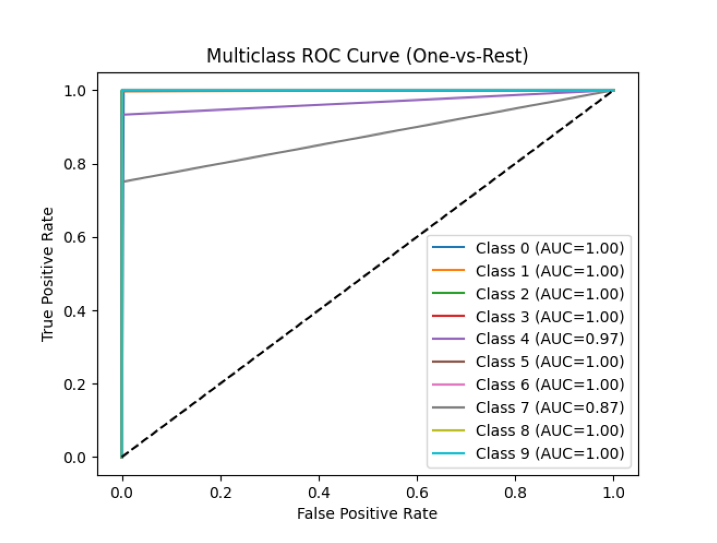

In [14]:
roc_path = os.path.join(artifact_uri, "roc_multiclass.png")

plot_curve(roc_path, (9,7))


## <a id="6" style="color: darkred; text-decoration: none;">6. Conclusions </a>

1️⃣ Report best per model type

Even if you ultimately pick one “best” model overall, it’s useful to keep track of the top performer in each family:

Model Type	Best Hyperparams	Metrics	Notes
NN	…	…	High accuracy, slower
Decision Tree	…	…	Slightly lower accuracy, very interpretable
Random Forest	…	…	High accuracy, medium interpretability

This lets you:

Compare across model families.

Justify choices for interpretability, speed, or memory.

Keep a record in MLflow or a notebook.

2️⃣ Include subjective criteria

If some quantities are not purely measurable (like interpretability, explainability, or deployment constraints), you can:

Add a column for “qualitative score”.

Document why a slightly worse metric may be acceptable (e.g., chose a tree for interpretability).

3️⃣ Notebook workflow

Use experiment_dashboard.ipynb to pull MLflow metrics.

Compare the best per model type and the overall best.

Include visualizations like:

Feature importances

Confusion matrices

ROC/PR curves (if relevant)

Add a short rationale for model choice, including subjective factors.

✅ Key principle

Objective metrics = primary filter.

Subjective criteria (interpretability, memory, deployment constraints) = secondary filter.

This approach makes your reporting transparent and reproducible, even if the final pick is not purely the highest metric.

In [ ]:
"""

feature importance for trees

import matplotlib.pyplot as plt
import pandas as pd

# Suppose 'model' is your trained tree/random forest model
# and 'feature_names' is a list of column names
feature_importances = model.feature_importances_
feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importances
}).sort_values("importance", ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(feat_df["feature"], feat_df["importance"], color="skyblue")
plt.gca().invert_yaxis()  # largest on top
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()
"""

Notes:

For NNs, feature importance is less straightforward; you could use:

Permutation importance

SHAP values

Integrated gradients (for deep models)

For a quick overview, tree-based importances are usually enough.

If you want, I can draft a generic notebook snippet that:

Pulls the best model per type from MLflow

Shows feature importance plots for tree models

And optionally SHAP plots for NN models